In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("sample_data/california_housing_train.csv")

print(df.head())
print(df.info())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  
0      1015.0       472.0         1.4936             66900.0  
1      1129.0       463.0         1.8200             80100.0  
2       333.0       117.0         1.6509             85700.0  
3       515.0       226.0         3.1917             73400.0  
4       624.0       262.0         1.9250             65500.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------   

In [ ]:
# 3. POPULATION STATISTICS
# ================================
population_mean = df['median_house_value'].mean()
population_median = df['median_house_value'].median()
population_std = df['median_house_value'].std()

print("\nPopulation Statistics:")
print("Mean:", population_mean)
print("Median:", population_median)
print("Std Dev:", population_std)


Population Statistics:
Mean: 207300.91235294117
Median: 180400.0
Std Dev: 115983.76438720913


In [ ]:
# 4. RANDOM SAMPLE (100)
# ================================
sample = df.sample(n=100, random_state=42)

sample_mean = sample['median_house_value'].mean()
sample_median = sample['median_house_value'].median()
sample_std = sample['median_house_value'].std()

print("\nSample Statistics:")
print("Mean:", sample_mean)
print("Median:", sample_median)
print("Std Dev:", sample_std)


Sample Statistics:
Mean: 215597.06
Median: 186250.0
Std Dev: 118718.60380032848


In [ ]:
# 5. COMPARISON
# ================================
print("\nComparison:")
print("Population Mean vs Sample Mean:", population_mean, sample_mean)



Comparison:
Population Mean vs Sample Mean: 207300.91235294117 215597.06


In [ ]:
# 6. SAMPLING METHODS
# ================================

# Simple Random Sampling
simple_sample = df.sample(n=100, random_state=1)

# Stratified Sampling (e.g., by Housing Median Age)
stratified_sample = df.groupby('housing_median_age', group_keys=False).apply(lambda x: x.sample(min(len(x), 5)))

# Systematic Sampling
k = len(df) // 100
systematic_sample = df.iloc[::k]

/tmp/ipykernel_457/3786605696.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = df.groupby('housing_median_age', group_keys=False).apply(lambda x: x.sample(min(len(x), 5)))


In [ ]:
# 7. ESTIMATION FROM SAMPLE
# ================================
sample_mean_est = sample['median_house_value'].mean()
sample_var_est = sample['median_house_value'].var()

print("\nEstimated Mean:", sample_mean_est)
print("Estimated Variance:", sample_var_est)


Estimated Mean: 215597.06
Estimated Variance: 14094106888.299368


In [ ]:
# 8. CONFIDENCE INTERVAL
# ================================
# Redefine sample and its statistics from cell mtRTg8RNZpVP to ensure they are available.
import numpy as np
sample = df.sample(n=100, random_state=42)
sample_mean = sample['median_house_value'].mean()
sample_std = sample['median_house_value'].std()

confidence = 0.95
n = len(sample)
mean = sample_mean
std_err = sample_std / np.sqrt(n)

ci = stats.t.interval(confidence, df=n-1, loc=mean, scale=std_err)

print("\n95% Confidence Interval:", ci)


95% Confidence Interval: (np.float64(192040.7133879945), np.float64(239153.4066120055))


In [ ]:
# 9. ONE SAMPLE T-TEST
# ================================
t_stat, p_val = stats.ttest_1samp(sample['median_house_value'], 200000)

print("\nT-test:")
print("t-statistic:", t_stat)
print("p-value:", p_val)

if p_val < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")


T-test:
t-statistic: 1.3137839816775903
p-value: 0.1919552435028917
Fail to Reject H0


In [ ]:
# 10. CHI-SQUARE TEST
# ================================
# Bin median_income to create categorical groups
df['median_income_cat'] = pd.cut(df['median_income'],
                                   bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf],
                                   labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

contingency_table = pd.crosstab(df['housing_median_age'], df['median_income_cat'])

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("\nChi-Square Test:")
print("Chi2:", chi2)
print("p-value:", p)

if p < 0.05:
    print("Variables are dependent")
else:
    print("Variables are independent")


Chi-Square Test:
Chi2: 963.280459500573
p-value: 8.107493140389487e-99
Variables are dependent


In [ ]:
# 11. ANOVA TEST
# ================================
groups = [group['median_house_value'].values for name, group in df.groupby('housing_median_age')]

f_stat, p_val_anova = stats.f_oneway(*groups)

print("\nANOVA Test:")
print("F-statistic:", f_stat)
print("p-value:", p_val_anova)

if p_val_anova < 0.05:
    print("Mean prices differ significantly")
else:
    print("No significant difference")


ANOVA Test:
F-statistic: 11.207903549019392
p-value: 2.0468219474177636e-87
Mean prices differ significantly


In [ ]:
# 12. MANN-WHITNEY U TEST
# ================================
# Compare median_house_value for houses with median_income below/above overall median
median_income_threshold = df['median_income'].median()
group_low_income = df[df['median_income'] <= median_income_threshold]['median_house_value']
group_high_income = df[df['median_income'] > median_income_threshold]['median_house_value']

u_stat, p_val_u = stats.mannwhitneyu(group_low_income, group_high_income)

print("\nMann-Whitney U Test:")
print("U-statistic:", u_stat)
print("p-value:", p_val_u)

if p_val_u < 0.05:
    print("Reject H0 (Difference exists)")
else:
    print("Fail to Reject H0")


Mann-Whitney U Test:
U-statistic: 12661789.0
p-value: 0.0
Reject H0 (Difference exists)


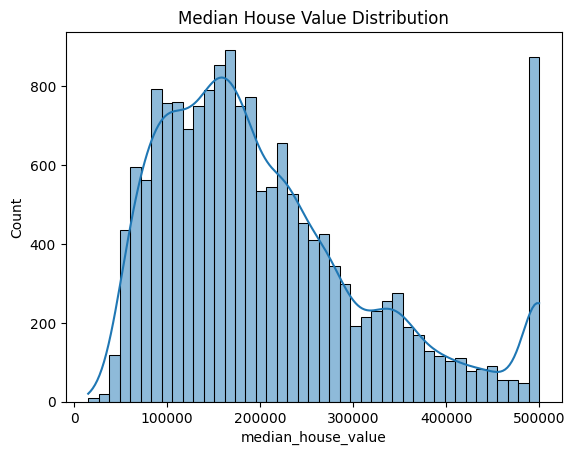

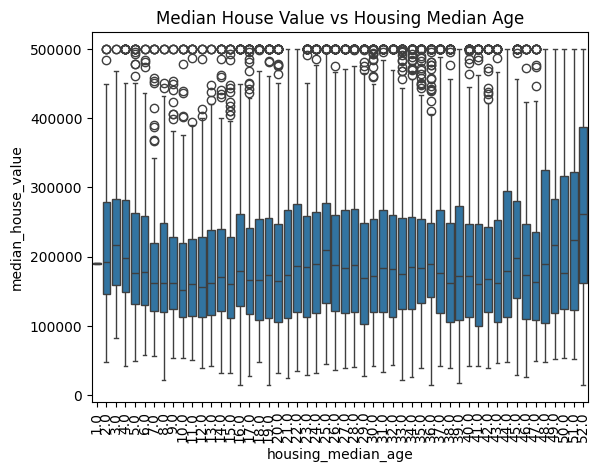

In [ ]:
# 13. VISUALIZATION (OPTIONAL BUT GOOD FOR VIVA)
# ================================
plt.figure()
sns.histplot(df['median_house_value'], kde=True)
plt.title("Median House Value Distribution")
plt.show()
print("\n")
plt.figure()
sns.boxplot(x='housing_median_age', y='median_house_value', data=df)
plt.xticks(rotation=90)
plt.title("Median House Value vs Housing Median Age")
plt.show()